In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from datetime import datetime

In [1]:
# Basic Event Representation
event = {
    't': 1234567,      # timestamp (microseconds)
    'x': 120,          # x coordinate (column)
    'y': 80,           # y coordinate (row)
    'p': 1             # polarity (1=ON, 0=OFF)
}

In [6]:
# Simulate events from a moving object
event_stream = [
    {'t': 0,     'x': 50, 'y': 50, 'p': 1},  # Object appears (ON)
    {'t': 100,   'x': 52, 'y': 51, 'p': 1},  # Movement detected (ON)
    {'t': 150,   'x': 48, 'y': 49, 'p': 0},  # Trailing edge (OFF)
    {'t': 200,   'x': 54, 'y': 52, 'p': 1},  # Continued movement (ON)
    {'t': 250,   'x': 51, 'y': 50, 'p': 0},  # Trailing edge (OFF)
]

In [11]:
# event_streams has to be converted to a structured numpy array for further processing
# Create structured array
events_numpy = np.array(
    [(evt['t'], evt['x'], evt['y'], evt['p']) for evt in event_stream],
    dtype=[('t', np.int64), ('x', np.int16), ('y', np.int16), ('p', np.uint8)]
)

print(f"Array shape: {events_numpy.shape}")
print(f"Array dtype: {events_numpy.dtype}")
print(f"\nFirst 3 events:")
print(events_numpy[:3])
print()

Array shape: (5,)
Array dtype: [('t', '<i8'), ('x', '<i2'), ('y', '<i2'), ('p', 'u1')]

First 3 events:
[(  0, 50, 50, 1) (100, 52, 51, 1) (150, 48, 49, 0)]



In [12]:
# Access individual components
print("Accessing components:")
print(f"  All timestamps: {events_numpy['t']}")
print(f"  All X coords:   {events_numpy['x']}")
print(f"  All Y coords:   {events_numpy['y']}")
print(f"  All polarities: {events_numpy['p']}")
print()

Accessing components:
  All timestamps: [  0 100 150 200 250]
  All X coords:   [50 52 48 54 51]
  All Y coords:   [50 51 49 52 50]
  All polarities: [1 1 0 1 0]



Text(0.5, 1.0, 'Event Locations (Color = Polarity)')

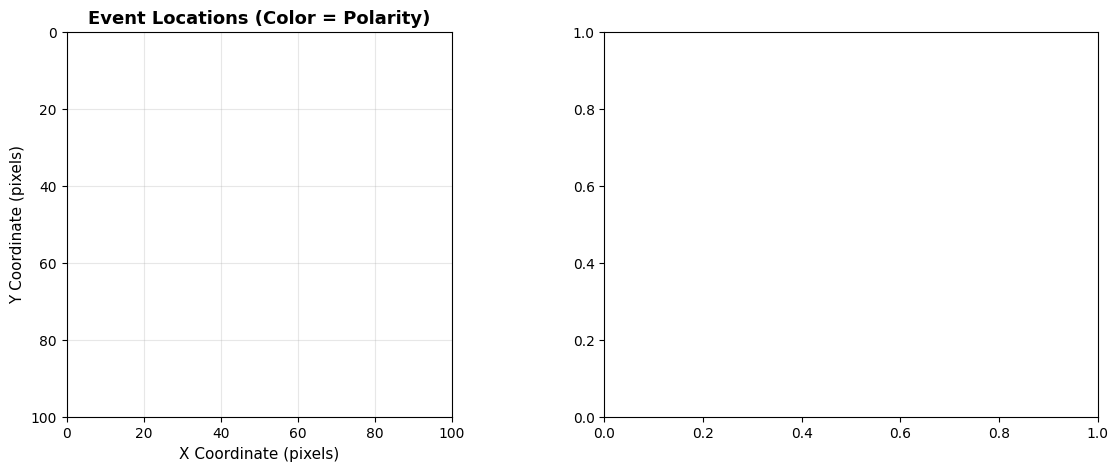

In [13]:
# Visualizing Events on a Spatial Grid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Simulate sensor dimensions (UCSD Ped2: 240x360)
sensor_height, sensor_width = 100, 100
# Plot 1: Event locations with polarity
ax1.set_xlim(0, sensor_width)
ax1.set_ylim(0, sensor_height)
ax1.set_aspect('equal')
ax1.invert_yaxis()  # Match image coordinates (y increases downward)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('X Coordinate (pixels)', fontsize=11)
ax1.set_ylabel('Y Coordinate (pixels)', fontsize=11)
ax1.set_title('Event Locations (Color = Polarity)', fontsize=13, fontweight='bold')

In [14]:
# Plot events
for i, evt in enumerate(event_stream):
    color = 'green' if evt['p'] == 1 else 'red'
    marker = '^' if evt['p'] == 1 else 'v'
    ax1.scatter(evt['x'], evt['y'], c=color, s=200, marker=marker, 
                edgecolors='black', linewidths=2, zorder=3, alpha=0.8)
    ax1.annotate(f"{i+1}", (evt['x'], evt['y']), 
                xytext=(3, 3), textcoords='offset points', 
                fontsize=9, fontweight='bold')

# Legend
on_patch = mpatches.Patch(color='green', label='ON (p=1): Brightness ↑')
off_patch = mpatches.Patch(color='red', label='OFF (p=0): Brightness ↓')
ax1.legend(handles=[on_patch, off_patch], loc='upper right')

In [19]:
# Plot 2: Events over time (timeline)
ax2.set_xlim(0, max(evt['t'] for evt in event_stream) + 50)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel('Time (microseconds)', fontsize=11)
ax2.set_ylabel('Polarity', fontsize=11)
ax2.set_title('Event Timeline (Polarity vs Time)', fontsize=13, fontweight='bold')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['OFF', 'ON'])
ax2.grid(True, alpha=0.3, axis='x')

In [ ]:
# Plot timeline
for i, evt in enumerate(event_stream):
    color = 'green' if evt['p'] == 1 else 'red'
    ax2.scatter(evt['t'], evt['p'], c=color, s=200, 
               edgecolors='black', linewidths=2, zorder=3, alpha=0.8)
    ax2.annotate(f"({evt['x']},{evt['y']})", 
                (evt['t'], evt['p']), 
                xytext=(0, 10), textcoords='offset points',
                fontsize=8, ha='center')

plt.tight_layout()
plt.show()